**Created by Justin Cooke, Feb 2nd, 2026**

Purpose of the script is to calculate the variance from the CPIES arrray (Johnson Exley et al., 2022) in the Freq. bands identified by the HYCOM spectral analysis

In [ ]:
# Import needed packages

# For numerical math/scientific computing
import numpy as np
import scipy as sp 
import seawater as sw
import scipy.sparse.linalg as sla
import scipy.io as spio
#import numba # Parallelization
import pyfftw 

# For manipulating/reading netCDF files
import netCDF4 as nc

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grdspc
import matplotlib.patches as patches
import matplotlib.animation as ani
from matplotlib.animation import FuncAnimation
import cmocean as cm # Plotting color schemes

# Set path to ffmpeg
plt.rcParams['animation.ffmpeg_path'] = '/home/jcooke/ExternalLibs/ffmpeg-git-20240629-amd64-static/ffmpeg'

# For loading files with common names
import glob

# Importing bathymetry (tiff)
import rasterio as geo

# General system stuff
import sys
import time
from datetime import date
from collections import OrderedDict
import pickle

today = date.today()

current_path = '/home/justin_cooke_uri_edu/DeepCyclones'

In [5]:
# Band-pass filter

from scipy.signal import butter, filtfilt

def butterfilt_bandpass(x, order, filtThi, filtTlo, sampT):
    """
    Band-pass Butterworth filter with zero-phase (forward–reverse) filtering.

    Parameters
    ----------
    x : array_like
        Input vector (row or column). Will be returned in the same orientation.
    order : int
        Order of the Butterworth filter.
    filtThi : float
        Longer period of the band (high cutoff).
    filtTlo : float
        Shorter period of the band (low cutoff).
    sampT : float
        Sampling period. Must have same units as filtThi/filtTlo.

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape (row/column) as input.
    """

    x = np.asarray(x)

    # Ensure input is 1-D vector
    if x.ndim != 1 and not (x.ndim == 2 and 1 in x.shape):
        raise ValueError("Input must be a vector, not an array.")

    # Preserve original orientation
    transpose_back = False
    if x.ndim == 2:
        if x.shape[0] == 1:  # row vector
            x = x.flatten()
            transpose_back = True
        elif x.shape[1] == 1:  # column vector
            x = x.flatten()
        else:
            raise ValueError("Input must be a vector, not a matrix.")

    n = x.size

    # Trend removal (linear ramp)
    t = np.arange(1, n + 1)
    P = np.polyfit([1, n], [x[0], x[-1]], 1)
    linear_trend = np.polyval(P, t)
    x_detrended = x - linear_trend

    # Normalized band edges (MATLAB: Wnlo = (2/filtTlo)*sampT)
    Wnlo = (2.0 / filtTlo) * sampT  # upper normalized cutoff
    Wnhi = (2.0 / filtThi) * sampT  # lower normalized cutoff
    Wn = [Wnhi, Wnlo]

    # Create Butterworth filter
    b, a = butter(order, Wn, btype='bandpass')

    # NaN check
    if np.isnan(x_detrended).any():
        raise ValueError("NaNs present in input data. Remove them before filtering.")

    # Zero-phase filtering
    out = filtfilt(b, a, x_detrended)

    # MATLAB code *comments out* adding the trend back:
    # out = out + linear_trend
    # For direct equivalence, we keep it commented.
    
    # Reshape to original orientation
    if transpose_back:
        out = out[np.newaxis, :]

    return out

# Low Pass Filter

from scipy.signal import butter, filtfilt

def lowpassfilt(data, filtT, sampT):
    """
    Low-pass filter a 1D data vector using a second-order Butterworth filter.
    Filtering is applied forward and backward to eliminate phase shift.

    Parameters
    ----------
    data : array_like
        Input data vector (1D array). Can be row or column oriented.
    filtT : float
        Filter period (same units as sampT).
    sampT : float
        Sampling period (same units as filtT).

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape as input.
    """

    data = np.asarray(data)
    if data.ndim != 1:
        raise ValueError("Input must be a 1D vector, not an array.")

    # Check if input was a row vector (for shape preservation)
    was_row = data.ndim == 1 and data.shape[0] < data.shape[-1]

    # Remove linear trend between endpoints
    n = len(data)
    x = np.arange(1, n + 1)
    p = np.polyfit([1, n], [data[0], data[-1]], 1)
    lineartrend = np.polyval(p, x)
    detrended = data - lineartrend

    # Check for NaNs
    if np.isnan(detrended).any():
        raise ValueError("Data contains NaNs; remove them before filtering.")

    # Butterworth filter setup
    # Wn is the normalized cutoff frequency (Nyquist = 0.5 / sampT)
    Wn = (2.0 / filtT) * sampT
    if Wn >= 1:
        raise ValueError("Cutoff frequency too high; ensure filtT > 2 * sampT.")
    b, a = butter(2, Wn)

    # Zero-phase filtering
    filtered = filtfilt(b, a, detrended)

    # Add linear trend back
    out = filtered + lineartrend

    # Preserve input orientation
    if was_row:
        out = out.reshape(1, -1)
    else:
        out = out.reshape(-1)

    return out

In [ ]:
# For plotting; have the bathymetry of the gulf

ds_gulf = geo.open('/home/justin_cooke_uri_edu/DeepCyclones/gulf.tiff')
#ds_gulf = geo.open('../gulf.tiff')
img = ds_gulf.read(1)

(gm,gn) = np.shape(img)
gulf_lon = np.linspace(-90,-82,gn)
gulf_lat = np.linspace(22,28,gm)

# To get the aspect ratio right
ymid = np.mean(gulf_lat)
ymid_rad = ymid*np.pi/180

# For plotting: labels

lon_xticks = np.array((-90,-89,-88,-87,-86,-85,-84,-83))
lon_xticklbls = ['$90^\circ$W','$89^\circ$W','$88^\circ$W','$87^\circ$W','$86^\circ$W','$85^\circ$W','$84^\circ$W','$83^\circ$W']

lat_yticks = np.array((22,23,24,25,26,27,28))
lat_yticklbls = ['$22^\circ$N','$23^\circ$N','$24^\circ$N','$25^\circ$N','$26^\circ$N','$27^\circ$N','$28^\circ$N']

In [4]:
# Load the CPIES data


ds_oi = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')
#ds_oi = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/Dynloop_OImapBottomPrs_40d_70k_65k_15Vn.mat')
#ds_oi = spio.loadmat('./ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')

oi_lat = ds_oi['OIprs']['lat'][0][0]
oi_lon = ds_oi['OIprs']['lon'][0][0]

# Let's grab that subset of data and then average to have 24 hour times 
oi_prs = ds_oi['OIprs']['prs'][0][0]

(nlat,nlon,nt) = oi_prs.shape

oi_prs_daily = np.zeros((nlat,nlon,nt))


countMe = 0
j = 0
while j < ((nt) - 1):
    firstHalf = oi_prs[:,:,j]
    secondHalf = oi_prs[:,:,j+1]

    avg_val = (firstHalf + secondHalf) / 2 
    oi_prs_daily[:,:,countMe] = avg_val
    
    countMe += 1
    
    j += 2

# output: [lat x lon x time]
oi_eref_daily = (oi_prs_daily*np.power(10,4))/(1040*9.81) # converts from pres to eta ref

In [ ]:
# Bandpass the data

filtThi = 60.0 # Low Freq filter
filtTlo = 30.0 # High Freq filter
sc = 1.0 # Sampling Freq (days)

bp_etaref = np.zeros_like(oi_eref_daily)
for i in range(nlat):
    for j in range(nlon):
        this_ts = oi_eref_daily[i,j,:]

        bp_etaref[i,j,:] = butterfilt_bandpass(this_ts,2,filtThi,filtTlo,sc)

# Get variance
bp_etaref_var = np.var(bp_etaref,axis=2)
fig,ax = plt.subplots(figsize=(8,8))

cb = plt.contourf(oi_lon,oi_lat,bp_etaref_var,cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
#cb = plt.contourf(oi_lon,oi_lat,np.var(oi_eref_daily,axis=2),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')
plt.contour(gulf_lon,gulf_lat,np.flipud(img),levels=[-3000,-2500,-2000],colors='black',linestyles='-')
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('2-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)
ax.text(-89.5,22.5,'CPIES Array',fontsize=20)

#fig.savefig(f'./Figures/CPIES_Var/BP_CPIES_{int(filtThi)}to{int(filtTlo)}_var_{today}.svg',format='svg')

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3609833/2107765105.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m^2$]')
/tmp/ipykernel_3609833/2107765105.py:30: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('2-year Mean of $\eta_{ref}$',fontsize=18)


Text(-89.5, 22.5, 'CPIES Array')

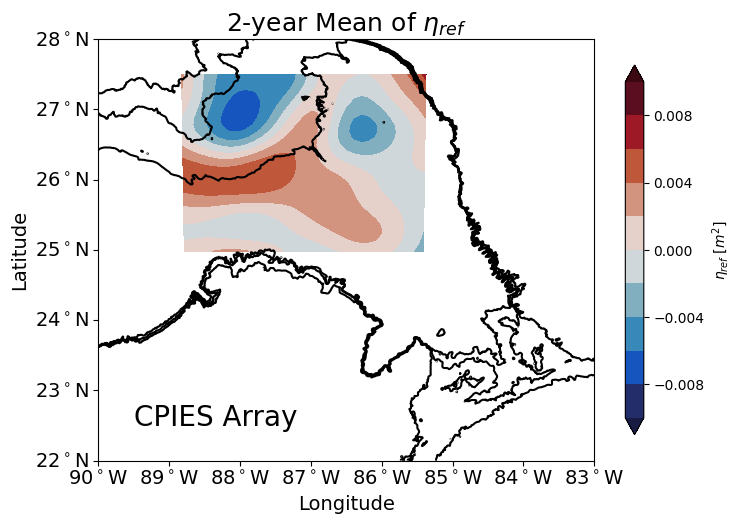

In [16]:
# Lowpass the data

filtTlo = 10.0 # High Freq filter
sc = 1.0 # Sampling Freq (days)

lp_etaref = np.zeros_like(oi_eref_daily)
for i in range(nlat):
    for j in range(nlon):
        this_ts = oi_eref_daily[i,j,:]

        lp_etaref[i,j,:] = lowpassfilt(this_ts,filtTlo,sc)

# Get the mean
lp_etaref_mean = np.nanmean(lp_etaref,axis=2)
fig,ax = plt.subplots(figsize=(8,8))

cb = plt.contourf(oi_lon,oi_lat,lp_etaref_mean,cmap=cm.cm.balance,levels=np.linspace(-0.01,0.01,11),extend='both')
#cb = plt.contourf(oi_lon,oi_lat,np.var(oi_eref_daily,axis=2),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m^2$]')
plt.contour(gulf_lon,gulf_lat,np.flipud(img),levels=[-3000,-2500,-2000],colors='black',linestyles='-')
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
ax.set_title('2-year Mean of $\eta_{ref}$',fontsize=18)
ax.text(-89.5,22.5,'CPIES Array',fontsize=20)
